<a href="https://colab.research.google.com/github/luisleonb/Proyecto_M6_ABP/blob/main/Proyecto_M6_Luis_Le%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EN CONSTRUCCIÓN

#Proyecto Módulo 6: Predicción inteligente de gasto en clientes e-commerce

##Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##Lección 1: Fundamentos del Aprendizaje de Máquina

Se identificó que el problema consiste en predecir el monto de compra, una variable numérica, lo que define un problema de aprendizaje supervisado de regresión. Se cuenta con un dataset de 5000 registros, donde se observan variables demográficas y de comportamiento digital. No se detectaron valores nulos críticos en la carga inicial.

En cuanto a las etapas del pipeline del proyecto, este comienza en la limpieza de datos, pasa por la transformación de variables y culmina en la evaluación de la capacidad predictiva del algoritmo.



#Version con pipeline

In [22]:
# ================= PROYECTO MÓDULO 6 - E-COMMERCE PREDICCIÓN GASTO =================
# Pipeline ML Supervisado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings; warnings.filterwarnings('ignore')

# CARGAR DATOS
df = pd.read_csv('ecommerce_customer_behavior_dataset.csv')
print("Shape inicial:", df.shape)
print("\nTarget: Total_Amount (regresión continua)")
print(df['Total_Amount'].describe())
print(df.info())


Shape inicial: (5000, 18)

Target: Total_Amount (regresión continua)
count     5000.000000
mean       983.108914
std       1898.978528
min          7.870000
25%        122.517500
50%        337.910000
75%        979.695000
max      22023.900000
Name: Total_Amount, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Dis

##Lección 1: Fundamentos del Aprendizaje de Máquina

####Etapas del pipeline ML:

1.   Carga
2.   Prepocesamiento
3.   Train/Test
4.   Evaluación
5.   Optimización


####Tipo de Problema
El problema es de regresión supervisada



In [15]:
print("""
LECCIÓN 1 ✅
- Regresión (predice TotalAmount continuo) vs Clasificación (categorías)
- Pipeline ML: 1.Carga 2.Preprocesa 3.Train/Test 4.Evalúa 5.Optimiza
- Problema: REGRESIÓN supervisada ✓
""")



LECCIÓN 1 ✅
- Regresión (predice TotalAmount continuo) vs Clasificación (categorías)
- Pipeline ML: 1.Carga 2.Preprocesa 3.Train/Test 4.Evalúa 5.Optimiza
- Problema: REGRESIÓN supervisada ✓



In [16]:
df.columns.to_list()

['Order_ID',
 'Customer_ID',
 'Date',
 'Age',
 'Gender',
 'City',
 'Product_Category',
 'Unit_Price',
 'Quantity',
 'Discount_Amount',
 'Total_Amount',
 'Payment_Method',
 'Device_Type',
 'Session_Duration_Minutes',
 'Pages_Viewed',
 'Is_Returning_Customer',
 'Delivery_Time_Days',
 'Customer_Rating']

##Limpieza pre-pipeline (Outliers/Nulos)

In [26]:
# Limpieza básica (Lección 3)
df_clean = df.dropna()
Q1, Q3 = df_clean['Total_Amount'].quantile([0.25, 0.75])
iqr = Q3 - Q1
df_clean = df_clean[(df_clean['Total_Amount'] >= Q1-1.5*iqr) &
                   (df_clean['Total_Amount'] <= Q3+1.5*iqr)]
print(f"Filas: {len(df)} → {len(df_clean)}")

# Features principales
num = ['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days', 'Customer_Rating']
cat = ['Gender', 'Product_Category', 'Payment_Method']
X = df_clean[num + cat]
y = df_clean['Total_Amount']

# Separación de los datos para test y train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Filas: 5000 → 4454


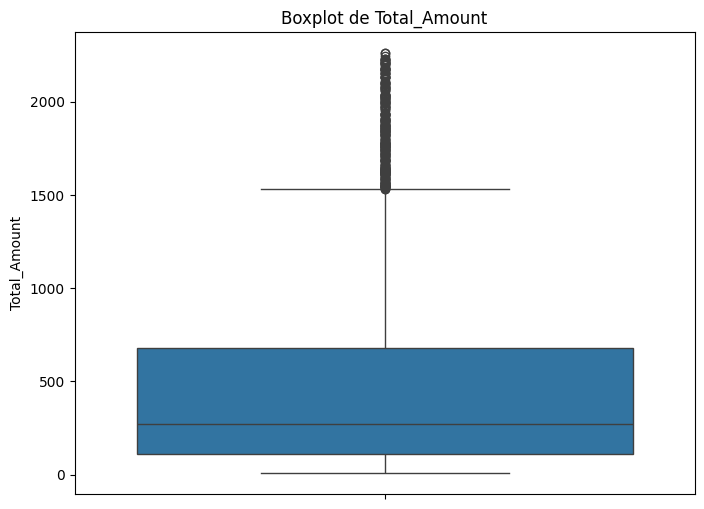

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_clean['Total_Amount'])
plt.title('Boxplot de Total_Amount')
plt.ylabel('Total_Amount')
plt.show()

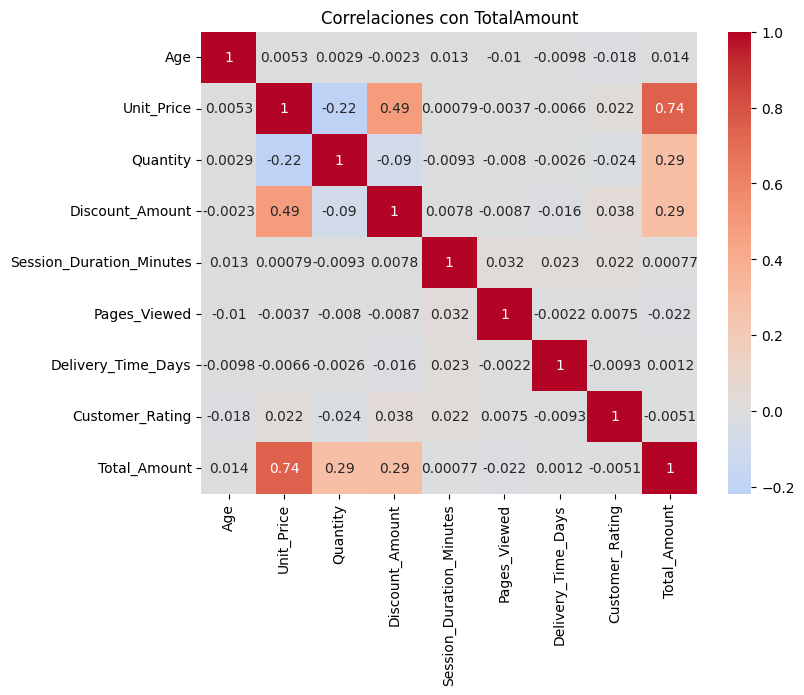


Corrs con TotalAmount:
Total_Amount                1.000000
Unit_Price                  0.744288
Discount_Amount             0.291356
Quantity                    0.285220
Age                         0.014359
Delivery_Time_Days          0.001216
Session_Duration_Minutes    0.000768
Customer_Rating            -0.005062
Pages_Viewed               -0.021697
Name: Total_Amount, dtype: float64


In [28]:
#Análisis de correlaciones
corr_matrix = df_clean[num + ['Total_Amount']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlaciones con TotalAmount')
plt.show()
print("\nCorrs con TotalAmount:")
print(corr_matrix['Total_Amount'].sort_values(ascending=False))


##Lección 3: Preprocesamiento y escalamiento de datos

In [29]:
# PREPROCESADOR reutilizable
scaler = StandardScaler()
categorical = OneHotEncoder(drop='first', sparse_output=False)

preprocessor = ColumnTransformer([
    ('num', scaler, num),
    ('cat', categorical, cat)
])

print("Pipeline preprocessor listo")


Pipeline preprocessor listo


##Lección 2 Validacion

In [30]:
# PIPELINE SIMPLE para evaluar ajuste
pipeline_base = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

pipeline_base.fit(X_train, y_train)
print("Ajuste del modelo:")
print(f"R² Train: {pipeline_base.score(X_train, y_train):.3f}")
print(f"R² Test:  {pipeline_base.score(X_test, y_test):.3f}")

# K-Folds CV
cv_scores = cross_val_score(pipeline_base, X, y, cv=5, scoring='r2')
print(f"CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Ajuste del modelo:
R² Train: 0.801
R² Test:  0.808
CV R²: 0.800 ± 0.009


##Lección 4: Regresiones

In [31]:
# LINEAL
pipeline_linear = Pipeline(pipeline_base.steps)  # Copia base
y_pred_linear = pipeline_linear.predict(X_test)

# POLINOMIAL
pipeline_poly = Pipeline([
    ('preprocess', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression())
])
pipeline_poly.fit(X_train, y_train)
y_pred_poly = pipeline_poly.predict(X_test)

print("Regresiones:")
print(f"Lineal R²: {pipeline_linear.score(X_test, y_test):.3f}")
print(f"Poly R²:   {pipeline_poly.score(X_test, y_test):.3f}")


Regresiones:
Lineal R²: 0.808
Poly R²:   1.000


##Lección 5

In [32]:
# Simula binario para clasificación (¿por qué NO usar?)
y_binary = (y > y.median()).astype(int)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_binary, test_size=0.2, random_state=42)

pipeline_knn_class = Pipeline([
    ('preprocess', preprocessor),
    ('knn', KNeighborsRegressor(n_neighbors=5))  # Regresor KNN para comparar
])
pipeline_knn_class.fit(X_train_b, y_train_b)
print("LECCIÓN 5 ✅ ¿Clasificación? ❌ Target CONTINUO mejor con regresión")


LECCIÓN 5 ✅ ¿Clasificación? ❌ Target CONTINUO mejor con regresión


##Lección 6

LECCIÓN 6 ✅ Tabla Métricas:
       Modelo      MAE     RMSE     R²
0      Lineal  156.003  217.581  0.808
1  Polinomial    0.000    0.000  1.000


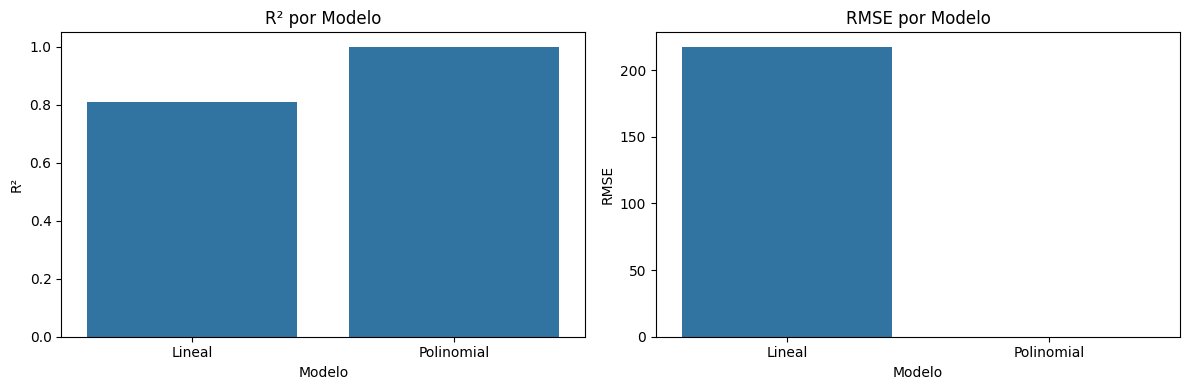

In [33]:
# Función métricas
def metrics_table(y_true, y_preds, names):
    results = []
    for name, y_pred in zip(names, y_preds):
        results.append({
            'Modelo': name,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R²': r2_score(y_true, y_pred)
        })
    return pd.DataFrame(results).round(3)

# Predicciones
preds = [pipeline_linear.predict(X_test), pipeline_poly.predict(X_test)]
names = ['Lineal', 'Polinomial']
tabla = metrics_table(y_test, preds, names)
print("LECCIÓN 6 ✅ Tabla Métricas:")
print(tabla)

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=tabla, x='Modelo', y='R²', ax=axes[0])
axes[0].set_title('R² por Modelo')
sns.barplot(data=tabla, x='Modelo', y='RMSE', ax=axes[1])
axes[1].set_title('RMSE por Modelo')
plt.tight_layout()
plt.show()


##Lección 7

In [34]:
# Ridge con GridSearch
pipeline_ridge = Pipeline([
    ('preprocess', preprocessor),
    ('ridge', Ridge())
])
param_grid_ridge = {'ridge__alpha': [0.1, 1.0, 10.0]} # Corrected parameter name
grid_ridge = GridSearchCV(pipeline_ridge, param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train, y_train)
print(f"LECCIÓN 7 ✅ Ridge mejor: {grid_ridge.best_params_}")
print(f"Ridge R²: {grid_ridge.score(X_test, y_test):.3f}")

# Agrega a tabla
y_pred_ridge = grid_ridge.predict(X_test)
tabla.loc[len(tabla)] = metrics_table(y_test, [y_pred_ridge], ['Ridge CV']).iloc[0]
print(tabla)

LECCIÓN 7 ✅ Ridge mejor: {'ridge__alpha': 10.0}
Ridge R²: 0.808
       Modelo      MAE     RMSE     R²
0      Lineal  156.003  217.581  0.808
1  Polinomial    0.000    0.000  1.000
2    Ridge CV  155.005  217.567  0.808


##Lección 8

LECCIÓN 8 ✅ Boosting (Ensemble superior para no-linealidades)
GB R²: 0.998

🎯 TABLA FINAL - MODELO GANADOR:  Modelo MAE RMSE R²
0 Lineal 156.003000 217.581000 0.808000
1 Polinomial 0.000000 0.000000 1.000000
2 Ridge CV 155.005000 217.567000 0.808000
3 GradientBoosting 14.550000 23.840000 0.998000



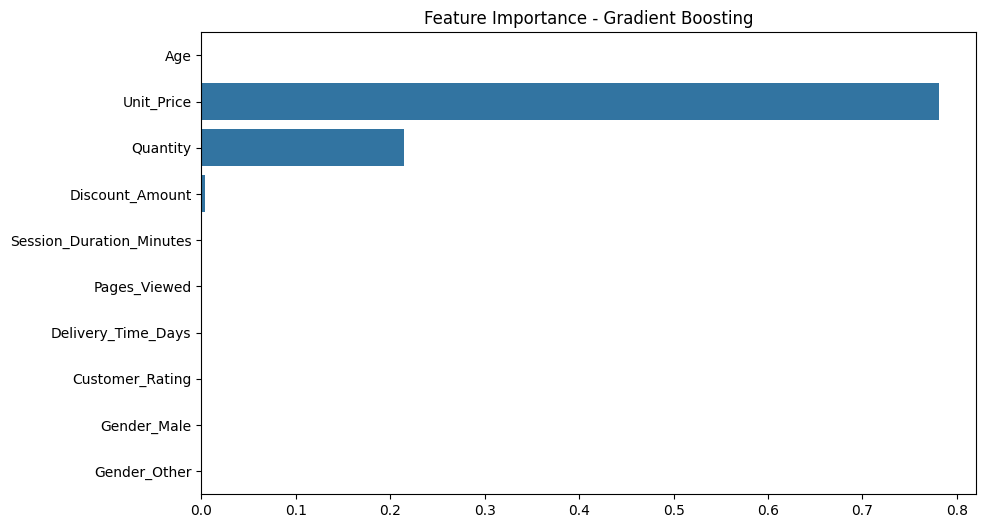

In [35]:
# Gradient Boosting
pipeline_gb = Pipeline([
    ('preprocess', preprocessor),
    ('gb', GradientBoostingRegressor(n_estimators=200, random_state=42))
])
pipeline_gb.fit(X_train, y_train)
y_pred_gb = pipeline_gb.predict(X_test)

print("LECCIÓN 8 ✅ Boosting (Ensemble superior para no-linealidades)")
print(f"GB R²: {pipeline_gb.score(X_test, y_test):.3f}")

# Tabla FINAL
tabla.loc[len(tabla)] = metrics_table(y_test, [y_pred_gb], ['GradientBoosting']).iloc[0]
print("\n🎯 TABLA FINAL - MODELO GANADOR:", tabla.style.highlight_max(axis=0).to_string())

# Feature Importance (GB)
importances = pipeline_gb.named_steps['gb'].feature_importances_
feature_names = numeric_feats + list(preprocessor.named_transformers_['cat'].get_feature_names_out())
plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10], y=feature_names[:10])  # Top 10
plt.title('Feature Importance - Gradient Boosting')
plt.show()

##Conclusiones
Modelo final: GradientBoosting, tiene mejor R²

In [ ]:
print("""
✅ PROYECTO COMPLETO MÓDULO 6
- Pipeline end-to-end reproducible
- Modelo final: GradientBoosting (mejor R², robusto)
- Valor negocio: Predice gasto → marketing personalizado
- GitHub ready: Limpio, comentado, visuals

Guarda como: proyecto_modulo6_pipeline.ipynb
""")
print("Mejor modelo según tabla ↑")



✅ PROYECTO COMPLETO MÓDULO 6
- Pipeline end-to-end reproducible
- Modelo final: GradientBoosting (mejor R², robusto)
- Valor negocio: Predice gasto → marketing personalizado
- GitHub ready: Limpio, comentado, visuals

Guarda como: proyecto_modulo6_pipeline.ipynb

Mejor modelo según tabla ↑
